## Importamos librerías

In [1]:
# === PARÁMETROS (Papermill los reemplaza con lo que envía n8n) ===
# Estos son solo valores por defecto para poder correr el notebook a mano.
TICKERS = ['AAPL', 'MSFT', 'GOOGL']   # lista de tickers — llega del formulario
ub =  0.01    # umbral de subida  (AJUSTA al valor que usabas)
us = -0.01    # umbral de bajada  (AJUSTA al valor que usabas)


In [2]:
# 'warnings' es parte de la librería estándar de Python: NO requiere pip install (se importa directamente).

In [3]:
import yfinance as yf # Librería para descargar datos financieros de Yahoo Finance
import pandas as pd # Librería para manipulación y análisis de datos en DataFrames
import numpy as np # Librería para computación numérica con arrays
import matplotlib.pyplot as plt # Librería para la creación de gráficos y visualizaciones
import warnings # Módulo para controlar mensajes de advertencia
warnings.filterwarnings('ignore') # Ignorar advertencias

import torch # Librería principal de PyTorch para construir y entrenar redes neuronales
import torch.nn as nn # Módulo de PyTorch para capas de redes neuronales
from torch.utils.data import TensorDataset, DataLoader # herramientas de PyTorch para manejar datasets y cargar datos

from sklearn.preprocessing import MinMaxScaler # Preprocesador para escalar características a un rango dado
from sklearn.metrics import mean_absolute_error, mean_squared_error # Métricas para evaluar el rendimiento del modelo

# Reproducibilidad — fija las semillas globales para que los resultados sean estables entre corridas
SEED = 42 # Semilla global del proyecto.
np.random.seed(SEED) # Fija el generador de números aleatorios de NumPy.
torch.manual_seed(SEED) # Fija el generador de números aleatorios de PyTorch.

print('✔ Librerías cargadas correctamente') # Imprime un mensaje indicando que las librerías se cargaron exitosamente
print(f'   PyTorch versión : {torch.__version__}') # Muestra la versión de PyTorch utilizada
print(f'   Dispositivo     : {"GPU" if torch.cuda.is_available() else "CPU"}') # Indica si se está usando GPU o CPU

✔ Librerías cargadas correctamente
   PyTorch versión : 2.12.0
   Dispositivo     : CPU


### Reproducibilidad

Fijamos una semilla global para NumPy y PyTorch. De esta manera los resultados son estables entre ejecuciones y la comparación entre Adam y SGD parte de la misma inicialización de pesos, asegurando que las diferencias se deban al optimizador y no al azar.

## Ingreso del ticker por el usuario

En este caso quisimos desarrollar un trabajo dinámico utilizando los datos financieros obtenidos desde Yahoo Finance, con el objetivo de facilitar el proceso de búsqueda y análisis del estado del mercado para el usuario.

A través del input implementado, la persona puede ingresar o especificar la empresa que desea analizar mediante su ticker. Posteriormente, el sistema realiza la consulta por medio de la API, extrae la información financiera correspondiente y la envía a toda la red y arquitectura de análisis que diseñamos.

Adicionalmente, además del ingreso del ticker, incorporamos una opción que permite seleccionar cuántos tickets o empresas se desean analizar simultáneamente. También implementamos una validación para verificar que las empresas ingresadas realmente existan dentro de la base de datos de Yahoo Finance, evitando errores en la consulta y garantizando la calidad de los datos procesados.

## Descarga del conjunto de datos

In [4]:
def descargar_ticker(ticker: str, auto_adjust=True) -> pd.DataFrame: # Define una función para descargar datos históricos de un ticker
    """
    Descarga el histórico completo de un ticker desde yfinance.
    Detecta el tipo de activo (Acción, ETF, Cripto, etc.) y
    el nombre completo de la empresa.
    """
    tk   = yf.Ticker(ticker) # Crea un objeto Ticker para el símbolo dado
    info = tk.info # Obtiene la información general del ticker

    mapa_tipo = { # Diccionario para mapear los tipos de activo de yfinance a nombres más amigables
        'EQUITY'        : 'Accion',
        'ETF'           : 'ETF',
        'INDEX'         : 'Indice',
        'MUTUALFUND'    : 'Fondo',
        'CRYPTOCURRENCY': 'Cripto',
        'CURRENCY'      : 'Divisa',
        'FUTURE'        : 'Futuro',
    }
    quote_type = (info.get('quoteType') or '').upper() # Obtiene el tipo de cotización y lo convierte a mayúsculas
    tipo       = mapa_tipo.get(quote_type, 'Desconocido') # Asigna un tipo de activo usando el mapa, o 'Desconocido' si no se encuentra
    empresa    = info.get('longName') or info.get('shortName') or ticker.upper() # Obtiene el nombre largo o corto de la empresa, o el ticker en mayúsculas

    df = yf.download( # Descarga los datos históricos del ticker
        ticker,
        period='max', # Descarga todo el historial disponible
        auto_adjust=auto_adjust, # Ajusta automáticamente los precios por splits y dividendos
        actions=True, # Incluye eventos de acciones como dividendos y splits
        progress=False, # No muestra la barra de progreso de descarga
    )

    if df.empty: # Verifica si el DataFrame resultante está vacío
        raise ValueError(f"No se encontraron datos para el ticker '{ticker}'.") # Lanza un error si no hay datos

    df = df.reset_index() # Restablece el índice del DataFrame, moviendo la columna 'Date' de índice a columna normal

    # Aplanar columnas MultiIndex si aparecen
    if isinstance(df.columns, pd.MultiIndex): # Comprueba si las columnas tienen un MultiIndex
        df.columns = df.columns.get_level_values(0) # Si es MultiIndex, aplana a un solo nivel usando el primer nivel

    df['Tipo']    = tipo # Añade una columna 'Tipo' con el tipo de activo detectado
    df['Empresa'] = empresa # Añade una columna 'Empresa' con el nombre de la empresa
    df['Ticker']  = ticker.upper() # Añade una columna 'Ticker' con el símbolo en mayúsculas

    return df # Retorna el DataFrame con los datos históricos y la información adicional


datos_crudos = {} # Inicializa un diccionario vacío para almacenar los DataFrames de datos crudos por ticker

print('=' * 60) # Imprime una línea divisoria para la interfaz de usuario
print(f'  Descargando datos de {len(TICKERS)} empresas...') # Muestra cuántas empresas se van a descargar
print('=' * 60) # Imprime otra línea divisoria

for ticker in TICKERS: # Itera sobre cada ticker en la lista de TICKERS seleccionados
    df_temp = descargar_ticker(ticker) # Llama a la función descargar_ticker para obtener los datos de cada ticker
    df_temp = df_temp.reset_index().rename(columns={'index': 'Date'})

    datos_crudos[ticker] = df_temp # Almacena el DataFrame resultante en el diccionario 'datos_crudos' usando el ticker como clave
    print(f"  ✔ {ticker:5s} — {len(df_temp):>5} filas | " # Imprime un mensaje de éxito con el ticker, número de filas y rango de fechas
          f"desde {df_temp['Date'].min().date()} "
          f"hasta {df_temp['Date'].max().date()}")

print('=' * 60) # Imprime una línea divisoria al final de la descarga
print('  Descarga completa.\n') # Indica que la descarga ha finalizado

  Descargando datos de 3 empresas...
  ✔ AAPL  — 11453 filas | desde 1980-12-12 hasta 2026-05-22
  ✔ MSFT  — 10127 filas | desde 1986-03-13 hasta 2026-05-22
  ✔ GOOGL —  5475 filas | desde 2004-08-19 hasta 2026-05-22
  Descarga completa.



Descargamos los precios ya ajustados por splits y dividendos (auto_adjust=True). Con esto evitamos saltos artificiales en el precio —como los que provoca un split de acciones— que no corresponden a movimientos reales del mercado y que distorsionaban nuestros log-retornos.

## Limpieza preventiva de datos y log-retornos

In [5]:
def limpiar_ticker(df: pd.DataFrame, ticker: str) -> pd.DataFrame: # Define una función para limpiar y preprocesar los datos de un ticker
    """
    Limpieza estándar para un DataFrame de precios:
      - Elimina filas con Close nulo o <= 0
      - Elimina duplicados de fecha
      - Ordena cronológicamente
      - Calcula log-retornos diarios
      - Detecta outliers con z-score (|z| > 4)
    """
    df = df.copy() # Crea una copia del DataFrame para evitar modificar el original

    # 1. Eliminar nulos en columnas críticas
    antes = len(df) # Almacena el número de filas antes de la eliminación de nulos
    df    = df.dropna(subset=['Close', 'Open', 'High', 'Low', 'Volume']) # Elimina filas donde 'Close', 'Open', 'High', 'Low' o 'Volume' sean nulos
    eliminados_nulos = antes - len(df) # Calcula cuántas filas fueron eliminadas debido a valores nulos

    # 2. Eliminar precios negativos o cero
    df = df[df['Close'] > 0] # Filtra el DataFrame para mantener solo las filas donde 'Close' sea mayor que 0

    # 3. Eliminar duplicados de fecha
    df = df.drop_duplicates(subset=['Date']) # Elimina filas duplicadas basándose en la columna 'Date', manteniendo la primera ocurrencia

    # 4. Ordenar cronológicamente
    df = df.sort_values('Date').reset_index(drop=True) # Ordena el DataFrame por 'Date' de forma ascendente y reinicia el índice

    # 5. Calcular log-retornos diarios
    df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1)) # Calcula el logaritmo de los retornos diarios (Close actual / Close anterior)
    df = df.dropna(subset=['LogReturn']).reset_index(drop=True) # Elimina la primera fila que tendrá un LogReturn nulo y reinicia el índice

    # 6. Detectar outliers (z-score sobre log-retornos)
    mu               = df['LogReturn'].mean() # Calcula la media de los log-retornos
    sigma            = df['LogReturn'].std() # Calcula la desviación estándar de los log-retornos
    df['ZScore']     = (df['LogReturn'] - mu) / sigma # Calcula el Z-score para cada log-retorno
    n_outliers       = (df['ZScore'].abs() > 4).sum() # Cuenta el número de outliers donde el valor absoluto del Z-score es mayor que 4

    print(f"  {ticker:5s} | filas: {len(df):>5} | " # Imprime un resumen de la limpieza para el ticker actual
          f"nulos eliminados: {eliminados_nulos:>2} | "
          f"outliers (|z|>4): {n_outliers:>3}")

    return df # Retorna el DataFrame limpio y preprocesado

In [6]:
datos_crudos = {} # Inicializa un diccionario vacío para almacenar los DataFrames de datos crudos, indexados por ticker.

print('=' * 60) # Imprime una línea de caracteres '=' para fines de formato en la salida.
print(f'  Descargando datos de {len(TICKERS)} empresas...') # Imprime un mensaje indicando cuántas empresas se van a descargar.
print('=' * 60) # Imprime otra línea de caracteres '=' para formato.

for ticker in TICKERS: # Itera sobre cada ticker en la lista global 'TICKERS'.
    df_temp = descargar_ticker(ticker) # Llama a la función 'descargar_ticker' para obtener los datos históricos del ticker actual.
    df_temp = df_temp.reset_index().rename(columns={'index': 'Date'})
    datos_crudos[ticker] = df_temp # Almacena el DataFrame descargado en el diccionario 'datos_crudos' usando el ticker como clave.
    print(f"  ✔ {ticker:5s} — {len(df_temp):>5} filas | " # Imprime un mensaje de éxito con el ticker, el número de filas del DataFrame, y el rango de fechas.
          f"desde {df_temp['Date'].min().date()} "
          f"hasta {df_temp['Date'].max().date()}")

print('=' * 60) # Imprime una línea de caracteres '=' para formato.
print('  Descarga completa.\n') # Imprime un mensaje indicando que la descarga ha finalizado, seguido de un salto de línea.

# ─────────────────────────────────────────────────────────────────
# 5.2  Limpieza
# ─────────────────────────────────────────────────────────────────
datos_limpios = {} # Inicializa un diccionario vacío para almacenar los DataFrames de datos limpios, indexados por ticker.

print('=' * 60) # Imprime una línea de caracteres '=' para fines de formato en la salida.
print('  Reporte de limpieza por empresa') # Imprime un encabezado para el reporte de limpieza.
print('=' * 60) # Imprime otra línea de caracteres '=' para formato.

for ticker in TICKERS: # Itera sobre cada ticker en la lista global 'TICKERS'.
    # Llama a la función 'limpiar_ticker' con el DataFrame crudo correspondiente y el ticker, y almacena el resultado en 'datos_limpios'.
    datos_limpios[ticker] = limpiar_ticker(datos_crudos[ticker], ticker)

print('=' * 60) # Imprime una línea de caracteres '=' final para formato.

  Descargando datos de 3 empresas...
  ✔ AAPL  — 11453 filas | desde 1980-12-12 hasta 2026-05-22
  ✔ MSFT  — 10127 filas | desde 1986-03-13 hasta 2026-05-22
  ✔ GOOGL —  5475 filas | desde 2004-08-19 hasta 2026-05-22
  Descarga completa.

  Reporte de limpieza por empresa
  AAPL  | filas: 11452 | nulos eliminados:  0 | outliers (|z|>4):  43
  MSFT  | filas: 10126 | nulos eliminados:  0 | outliers (|z|>4):  53
  GOOGL | filas:  5474 | nulos eliminados:  0 | outliers (|z|>4):  38


## Secuencias deslizantes

In [7]:
def crear_secuencias(data, input_len=30, output_len=5): # Define una función para crear secuencias de entrada y salida para el modelo
    X, y = [], [] # Inicializa listas vacías para almacenar las secuencias de entrada (X) y salida (y)
    for i in range(len(data) - input_len - output_len): # Itera sobre la serie de datos para crear las ventanas deslizantes
        X.append(data[i : i + input_len]) # Agrega la secuencia de 'input_len' elementos como entrada (X)
        y.append(data[i + input_len : i + input_len + output_len]) # Agrega la secuencia de 'output_len' elementos siguientes como salida (y)
    return np.array(X), np.array(y) # Retorna las listas convertidas a arrays de NumPy

## Arquitectura del Modelo — Encoder-Decoder MLP

### Encoder: comprime la secuencia de entrada en un vector latente

Recibe 30 días de log-retornos y los comprime en 32 números (z). La red decide sola qué información conservar en ese espacio reducido.

En este caso las capas definidas fueron 30 → 128 → 64 → 32

In [8]:
class EncoderMLP(nn.Module): # Define la clase EncoderMLP que hereda de nn.Module, el módulo base para todas las redes neuronales en PyTorch.
    """
    Red MLP que recibe una secuencia de input_len pasos y la
    codifica en un vector latente de dimensión latent_dim.
    Capas: Linear → ReLU → Dropout → Linear → ReLU → Linear
    """
    def __init__(self, input_len=30, latent_dim=32, dropout_p=0.2): # Define el constructor de la clase con parámetros para la longitud de entrada, dimensión latente y probabilidad de dropout.
        super().__init__() # Llama al constructor de la clase base nn.Module.
        self.red = nn.Sequential( # Define una secuencia de capas (una red neuronal Feedforward).
            nn.Linear(input_len, 128), # Primera capa lineal que mapea la entrada (input_len) a 128 neuronas.
            nn.ReLU(), # Función de activación ReLU para introducir no-linealidad.
            nn.Dropout(dropout_p),      # Capa de Dropout para regularización, previniendo el sobreajuste.
            nn.Linear(128, 64), # Segunda capa lineal que mapea de 128 a 64 neuronas.
            nn.ReLU(), # Otra función de activación ReLU.
            nn.Linear(64, latent_dim) # Tercera capa lineal que mapea de 64 neuronas a la dimensión latente (latent_dim).
        )

    def forward(self, x): # Define el método forward que especifica cómo se procesará la entrada a través de la red.
        return self.red(x) # Pasa la entrada 'x' a través de la secuencia de capas definida en 'self.red' y retorna la salida.

### Decoder: expande el vector latente a la secuencia de salida

In [9]:
class DecoderMLP(nn.Module): # Define la clase DecoderMLP que hereda de nn.Module, el módulo base para todas las redes neuronales en PyTorch.
    """
    Red MLP que recibe el vector latente y genera una secuencia
    de output_len pasos hacia el futuro.
    Capas: Linear → ReLU → Dropout → Linear → ReLU → Linear
    """
    def __init__(self, latent_dim=32, output_len=1, dropout_p=0.2): # Define el constructor de la clase con parámetros para la dimensión latente, longitud de salida y probabilidad de dropout.
        super().__init__() # Llama al constructor de la clase base nn.Module.
        self.red = nn.Sequential( # Define una secuencia de capas
            nn.Linear(latent_dim, 64), # Primera capa lineal que mapea el vector latente (latent_dim) a 64 neuronas.
            nn.ReLU(), # Función de activación ReLU para introducir no-linealidad.
            nn.Dropout(dropout_p),      # Capa de Dropout para regularización, previniendo el sobreajuste.
            nn.Linear(64, 128), # Segunda capa lineal que mapea de 64 a 128 neuronas.
            nn.ReLU(), # Otra función de activación ReLU.
            nn.Linear(128, output_len) # Tercera capa lineal que mapea de 128 neuronas a la longitud de salida (output_len).
        )

    def forward(self, z): # Define el método forward que especifica cómo se procesará el vector latente a través de la red.
        return self.red(z) # Pasa el vector latente 'z' a través de la secuencia de capas definida en 'self.red' y retorna la salida.

## Modelo completo: Encoder → vector latente → Decoder

In [10]:
class EncoderDecoder(nn.Module): # Define la clase EncoderDecoder que combina el Encoder y el Decoder, heredando de nn.Module.
    """
    Conecta el Encoder y el Decoder en un único módulo.
    Flujo: x (30) → Encoder → z (32) → Decoder → ŷ (5)
    """
    def __init__(self, input_len=30, latent_dim=32, output_len=1, dropout_p=0.2): # Define el constructor de la clase con parámetros para la longitud de entrada, dimensión latente, longitud de salida y probabilidad de dropout.
        super().__init__() # Llama al constructor de la clase base nn.Module.
        self.encoder = EncoderMLP(input_len, latent_dim, dropout_p) # Inicializa una instancia del EncoderMLP.
        self.decoder = DecoderMLP(latent_dim, output_len, dropout_p) # Inicializa una instancia del DecoderMLP.

    def forward(self, x): # Define el método forward que especifica cómo se procesará la entrada a través de la red completa.
        z = self.encoder(x) # Pasa la entrada 'x' a través del encoder para obtener el vector latente 'z'.
        return self.decoder(z) # Pasa el vector latente 'z' a través del decoder para obtener la salida predicha.


# Vista rápida de la arquitectura
modelo_demo = EncoderDecoder() # Crea una instancia del modelo EncoderDecoder con los parámetros por defecto.
print('Arquitectura Encoder-Decoder MLP:') # Imprime un encabezado para la arquitectura del modelo.
print(modelo_demo) # Imprime la representación de cadena del modelo, mostrando su estructura de capas.
total_params = sum(p.numel() for p in modelo_demo.parameters() if p.requires_grad) # Calcula el número total de parámetros entrenables en el modelo.
print(f'\nParámetros entrenables: {total_params:,}') # Imprime el número total de parámetros entrenables formateado.

Arquitectura Encoder-Decoder MLP:
EncoderDecoder(
  (encoder): EncoderMLP(
    (red): Sequential(
      (0): Linear(in_features=30, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=64, bias=True)
      (4): ReLU()
      (5): Linear(in_features=64, out_features=32, bias=True)
    )
  )
  (decoder): DecoderMLP(
    (red): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=64, out_features=128, bias=True)
      (4): ReLU()
      (5): Linear(in_features=128, out_features=1, bias=True)
    )
  )
)

Parámetros entrenables: 24,865


## Preprocesamiento — Normalización y Secuencias

In [11]:
# ─────────────────────────────────────────────────────────────────
# Parámetros globales de secuencias
# ─────────────────────────────────────────────────────────────────
INPUT_LEN  = 30   # Define la longitud de la secuencia de entrada para el encoder (en días).
OUTPUT_LEN = 1    # Define la longitud de la secuencia de salida a predecir por el decoder (en días).
SPLIT      = 0.8  # Define la proporción para dividir los datos en conjuntos de entrenamiento (80%) y prueba (20%).
VAL_FRAC   = 0.15 # Fracción del TRAIN reservada para validación (early stopping); el resto sigue siendo entrenamiento.

# ─────────────────────────────────────────────────────────────────
# Por cada empresa:
#   1. Separar serie en train/test ANTES de escalar (evita data leakage)
#   2. Ajustar MinMaxScaler SOLO con train
#   3. Crear secuencias deslizantes
#   4. Guardar scaler y split_idx para desnormalizar después
# ─────────────────────────────────────────────────────────────────
scalers      = {}   # Inicializa un diccionario para almacenar los objetos MinMaxScaler, uno por cada ticker, para desnormalizar.
split_indices = {}  # Inicializa un diccionario para almacenar el índice de corte entre train/test para cada ticker.

X_train_list, y_train_list = [], [] # Inicializa listas para almacenar las secuencias de entrada (X) y salida (y) del conjunto de entrenamiento.
X_test_list,  y_test_list  = [], [] # Inicializa listas para almacenar las secuencias de entrada (X) y salida (y) del conjunto de prueba.
X_val_list,   y_val_list   = [], [] # Inicializa listas para las secuencias de validación.

print(f'Configuración: ventana entrada={INPUT_LEN} días | salida={OUTPUT_LEN} días | split={int(SPLIT*100)}/{100 - int(SPLIT*100)}') # Imprime la configuración de las ventanas de entrada/salida y el split.
print('=' * 65) # Imprime una línea divisoria para formato.
print(f'  {"Ticker":6s} | {"Train seq":>10} | {"Val seq":>8} | {"Test seq":>10}') # Imprime el encabezado de la tabla de secuencias.
print('=' * 65) # Imprime otra línea divisoria para formato.

for ticker in TICKERS: # Itera sobre cada ticker en la lista global de tickers.
    df_t  = datos_limpios[ticker] # Obtiene el DataFrame limpio para el ticker actual.
    serie = df_t['LogReturn'].values # Extrae los valores de 'LogReturn' como una serie de NumPy.

    # Split temporal (sin mezclar futuro con pasado)
    split_idx          = int(len(serie) * SPLIT) # Calcula el índice para dividir la serie en conjuntos de entrenamiento y prueba.
    split_indices[ticker] = split_idx # Almacena el índice de división para el ticker actual.
    serie_train        = serie[:split_idx] # Divide la serie para obtener los datos de entrenamiento.
    serie_test         = serie[split_idx:] # Divide la serie para obtener los datos de prueba.

    # Normalización — fit SOLO en train
    scaler             = MinMaxScaler() # Crea una instancia de MinMaxScaler.
    serie_train_scaled = scaler.fit_transform( # Ajusta el scaler a los datos de entrenamiento y los transforma, luego los aplana.
                            serie_train.reshape(-1, 1)).flatten()
    serie_test_scaled  = scaler.transform( # Transforma los datos de prueba usando el scaler ajustado a los datos de entrenamiento, luego los aplana.
                            serie_test.reshape(-1, 1)).flatten()
    scalers[ticker]    = scaler # Almacena el scaler ajustado para el ticker actual.

    # Crear secuencias deslizantes
    X_tr, y_tr = crear_secuencias(serie_train_scaled, INPUT_LEN, OUTPUT_LEN) # Crea secuencias de entrada y salida para el conjunto de entrenamiento.
    X_te, y_te = crear_secuencias(serie_test_scaled,  INPUT_LEN, OUTPUT_LEN) # Crea secuencias de entrada y salida para el conjunto de prueba.

    # Reservar las últimas VAL_FRAC secuencias de train como VALIDACIÓN (más recientes, sin mezclar futuro con pasado)
    n_val = int(len(X_tr) * VAL_FRAC) # Número de secuencias que pasan a validación.
    if n_val > 0: # Solo separa validación si hay secuencias suficientes.
        X_val_list.append(X_tr[-n_val:]); y_val_list.append(y_tr[-n_val:]) # Las últimas n_val secuencias van a validación.
        X_tr, y_tr = X_tr[:-n_val], y_tr[:-n_val] # El resto queda como entrenamiento.

    X_train_list.append(X_tr);  y_train_list.append(y_tr) # Agrega las secuencias de entrenamiento a las listas.
    X_test_list.append(X_te);   y_test_list.append(y_te) # Agrega las secuencias de prueba a las listas.

    print(f'  {ticker:6s} | {len(X_tr):>10,} | {n_val:>8,} | {len(X_te):>10,}') # Imprime el número de secuencias (train/val/test) creadas para el ticker actual.

print('=' * 65) # Imprime una línea divisoria para formato.

# Concatenar todas las empresas en un único dataset
X_train_all = np.concatenate(X_train_list, axis=0) # Concatena todas las secuencias de entrada de entrenamiento en un solo array NumPy.
y_train_all = np.concatenate(y_train_list, axis=0) # Concatena todas las secuencias de salida de entrenamiento en un solo array NumPy.
X_test_all  = np.concatenate(X_test_list,  axis=0) # Concatena todas las secuencias de entrada de prueba en un solo array NumPy.
y_test_all  = np.concatenate(y_test_list,  axis=0) # Concatena todas las secuencias de salida de prueba en un solo array NumPy.
X_val_all   = np.concatenate(X_val_list,   axis=0) # Concatena las secuencias de entrada de validación.
y_val_all   = np.concatenate(y_val_list,   axis=0) # Concatena las secuencias de salida de validación.

print(f'\nDataset combinado:') # Imprime un encabezado para el dataset combinado.
print(f'  X_train: {X_train_all.shape}  |  y_train: {y_train_all.shape}') # Imprime las dimensiones de X_train y y_train combinados.
print(f'  X_test : {X_test_all.shape}   |  y_test : {y_test_all.shape}') # Imprime las dimensiones de X_test y y_test combinados.
print(f'  X_val  : {X_val_all.shape}    |  y_val  : {y_val_all.shape}')   # Imprime las dimensiones de X_val y y_val combinados.

# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train_all, dtype=torch.float32) # Convierte el array NumPy X_train_all a un tensor de PyTorch de tipo float32.
y_train_t = torch.tensor(y_train_all, dtype=torch.float32) # Convierte el array NumPy y_train_all a un tensor de PyTorch de tipo float32.
X_test_t  = torch.tensor(X_test_all,  dtype=torch.float32) # Convierte el array NumPy X_test_all a un tensor de PyTorch de tipo float32.
y_test_t  = torch.tensor(y_test_all,  dtype=torch.float32) # Convierte el array NumPy y_test_all a un tensor de PyTorch de tipo float32.
X_val_t   = torch.tensor(X_val_all,   dtype=torch.float32) # Convierte X_val_all a un tensor de PyTorch.
y_val_t   = torch.tensor(y_val_all,   dtype=torch.float32) # Convierte y_val_all a un tensor de PyTorch.

print(f'\n✔ Tensores listos para entrenamiento') # Imprime un mensaje indicando que los tensores están listos para el entrenamiento.

Configuración: ventana entrada=30 días | salida=1 días | split=80/20
  Ticker |  Train seq |  Val seq |   Test seq
  AAPL   |      7,761 |    1,369 |      2,260
  MSFT   |      6,859 |    1,210 |      1,995
  GOOGL  |      3,696 |      652 |      1,064

Dataset combinado:
  X_train: (18316, 30)  |  y_train: (18316, 1)
  X_test : (5319, 30)   |  y_test : (5319, 1)
  X_val  : (3231, 30)    |  y_val  : (3231, 1)

✔ Tensores listos para entrenamiento


##  Entrenamiento — Adam vs SGD

In [12]:
# ─────────────────────────────────────────────────────────────────
# Función genérica de entrenamiento
# Soporta cualquier optimizador, guarda historial de pérdida
# Aplica Early Stopping (paciencia configurable)
# ─────────────────────────────────────────────────────────────────
def entrenar_modelo(modelo, optimizador, loader, val_loader=None, epochs=100,
                    paciencia=10, nombre='Modelo'): # Define la función 'entrenar_modelo' que encapsula el bucle de entrenamiento.
    """
    Entrena el modelo con Early Stopping.
    Retorna el historial de pérdida por época.
    """
    criterio   = nn.MSELoss() # Define la función de pérdida a utilizar: Error Cuadrático Medio (Mean Squared Error).
    historial  = [] # Inicializa una lista para almacenar la pérdida en cada época.
    mejor_loss = float('inf') # Inicializa la mejor pérdida encontrada hasta el momento con un valor infinito.
    contador   = 0 # Inicializa un contador para el Early Stopping.

    print(f'  Entrenando con {nombre}...') # Imprime un mensaje indicando el inicio del entrenamiento para el modelo actual.

    for epoch in range(epochs): # Bucle principal de entrenamiento que se ejecuta por el número de épocas definidas.
        modelo.train() # Pone el modelo en modo de entrenamiento (activa dropout, batch norm, etc.).
        loss_epoch = 0 # Inicializa la pérdida acumulada para la época actual.

        for xb, yb in loader: # Itera sobre los lotes de datos proporcionados por el DataLoader.
            optimizador.zero_grad() # Reinicia los gradientes del optimizador a cero en cada paso.
            pred = modelo(xb) # Realiza una pasada hacia adelante (forward pass) para obtener las predicciones del modelo.
            loss = criterio(pred, yb) # Calcula la pérdida entre las predicciones y las etiquetas reales.
            loss.backward() # Realiza una pasada hacia atrás (backward pass) para calcular los gradientes.
            optimizador.step() # Actualiza los pesos del modelo utilizando los gradientes calculados.
            loss_epoch += loss.item() # Acumula la pérdida del lote actual.

        loss_epoch /= len(loader) # Calcula la pérdida promedio por lote para la época actual.
        historial.append(loss_epoch) # Añade la pérdida promedio de la época al historial.

        # ── Pérdida de VALIDACIÓN (sin gradientes): base correcta del early stopping ──
        if val_loader is not None: # Solo si se pasó un conjunto de validación.
            modelo.eval() # Modo evaluación (desactiva dropout) para medir generalización.
            with torch.no_grad(): # Sin cálculo de gradientes durante la validación.
                loss_val = sum(criterio(modelo(xb), yb).item() for xb, yb in val_loader) / len(val_loader) # Pérdida media de validación.
            loss_monitor = loss_val # El early stopping vigila la VALIDACIÓN, no el entrenamiento.
        else: # Sin validación: se mantiene el comportamiento anterior.
            loss_val = loss_epoch # Solo para el print.
            loss_monitor = loss_epoch # Monitorea el train (fallback).

        # Early Stopping (ahora sobre el loss de validación)
        if loss_monitor < mejor_loss: # Comprueba si la pérdida de validación mejoró.
            mejor_loss = loss_monitor # Actualiza la mejor pérdida de validación.
            contador   = 0 # Reinicia el contador de paciencia.
        else: # Si la pérdida no ha mejorado.
            contador += 1 # Incrementa el contador de paciencia.
            if contador >= paciencia: # Si el contador de paciencia ha alcanzado el límite.
                print(f'  Early stopping en época {epoch + 1} ' # Imprime un mensaje de Early Stopping.
                      f'(mejor loss: {mejor_loss:.6f})')
                break # Sale del bucle de épocas.

        if (epoch + 1) % 20 == 0: # Imprime el progreso cada 20 épocas.
            print(f'    Época {epoch + 1:>3} | Loss: {loss_epoch:.6f} | Val: {loss_val:.6f}')

    print(f'  ✔ {nombre} listo — épocas: {len(historial)} | ' # Imprime un mensaje final de entrenamiento completado.
          f'mejor loss: {mejor_loss:.6f}')
    return historial # Retorna el historial de pérdidas del entrenamiento.


# ─────────────────────────────────────────────────────────────────
# DataLoader compartido
# ─────────────────────────────────────────────────────────────────
dataset_train = TensorDataset(X_train_t, y_train_t) # Crea un objeto TensorDataset a partir de los tensores de entrenamiento.
loader        = DataLoader(dataset_train, batch_size=64, shuffle=True) # Crea un DataLoader para cargar los datos en lotes durante el entrenamiento.
dataset_val   = TensorDataset(X_val_t, y_val_t) # TensorDataset con el conjunto de validación.
val_loader    = DataLoader(dataset_val, batch_size=64, shuffle=False) # DataLoader de validación (sin shuffle; no se entrena sobre él).

# ─────────────────────────────────────────────────────────────────
# Entrenamiento con ADAM
# Regularización: Dropout (en el modelo) + Weight Decay (L2)
# ─────────────────────────────────────────────────────────────────
print('=' * 55) # Imprime una línea divisoria para formato.
print('  OPTIMIZADOR 1: Adam') # Imprime el nombre del optimizador a utilizar.
print('  lr=0.001 | weight_decay=1e-4 | dropout=0.2') # Muestra los hiperparámetros del optimizador Adam.
print('=' * 55) # Imprime otra línea divisoria para formato.

torch.manual_seed(SEED) # Misma inicialización de pesos para comparar Adam vs SGD de forma justa y reproducible.
modelo_adam = EncoderDecoder(input_len=INPUT_LEN, output_len=OUTPUT_LEN, # Instancia el modelo EncoderDecoder para el optimizador Adam.
                              dropout_p=0.2) # Define la probabilidad de dropout.
opt_adam    = torch.optim.Adam(modelo_adam.parameters(), # Inicializa el optimizador Adam con los parámetros del modelo.
                                lr=0.001, weight_decay=1e-4) # Configura la tasa de aprendizaje (lr) y el peso de decaimiento (L2).

hist_adam   = entrenar_modelo(modelo_adam, opt_adam, loader, val_loader=val_loader, # Llama a la función de entrenamiento (early stopping sobre validación).
                               epochs=100, paciencia=10, nombre='Adam') # Configura el número máximo de épocas, paciencia para Early Stopping y nombre.

# ─────────────────────────────────────────────────────────────────
# Entrenamiento con SGD
# Regularización: Dropout (en el modelo) + Weight Decay (L2) + momentum
# ─────────────────────────────────────────────────────────────────
print() # Imprime una línea en blanco para separación.
print('=' * 55) # Imprime una línea divisoria para formato.
print('  OPTIMIZADOR 2: SGD') # Imprime el nombre del optimizador a utilizar.
print('  lr=0.01 | momentum=0.9 | weight_decay=1e-4 | dropout=0.2') # Muestra los hiperparámetros del optimizador SGD.
print('=' * 55) # Imprime otra línea divisoria para formato.

torch.manual_seed(SEED) # Reinicia la semilla: SGD arranca de la misma inicialización que Adam.
modelo_sgd  = EncoderDecoder(input_len=INPUT_LEN, output_len=OUTPUT_LEN, # Instancia un nuevo modelo EncoderDecoder para el optimizador SGD.
                              dropout_p=0.2) # Define la probabilidad de dropout.
opt_sgd     = torch.optim.SGD(modelo_sgd.parameters(), # Inicializa el optimizador SGD con los parámetros del modelo.
                               lr=0.01, momentum=0.9, weight_decay=1e-4) # Configura la tasa de aprendizaje, momento y peso de decaimiento.

hist_sgd    = entrenar_modelo(modelo_sgd, opt_sgd, loader, val_loader=val_loader, # Llama a la función de entrenamiento (early stopping sobre validación).
                               epochs=100, paciencia=10, nombre='SGD') # Configura el número máximo de épocas, paciencia para Early Stopping y nombre.

  OPTIMIZADOR 1: Adam
  lr=0.001 | weight_decay=1e-4 | dropout=0.2
  Entrenando con Adam...
    Época  20 | Loss: 0.002084 | Val: 0.002666
  Early stopping en época 23 (mejor loss: 0.002349)
  ✔ Adam listo — épocas: 23 | mejor loss: 0.002349

  OPTIMIZADOR 2: SGD
  lr=0.01 | momentum=0.9 | weight_decay=1e-4 | dropout=0.2
  Entrenando con SGD...
    Época  20 | Loss: 0.002579 | Val: 0.001893
  Early stopping en época 21 (mejor loss: 0.001571)
  ✔ SGD listo — épocas: 21 | mejor loss: 0.001571


##  Predicción y Métricas por Empresa

In [13]:
def direccion_real(precios, precio_base, ub, us):
    """
    Clasifica la dirección del movimiento del precio:
        SUBE  -> si supera umbral superior
        BAJA  -> si cae debajo del umbral inferior
        IGUAL -> si queda entre ambos
    """

    direcciones = []

    for p in precios:
        variacion = (p - precio_base) / precio_base

        if variacion > us:
            direcciones.append('SUBE')

        elif variacion < -ub:
            direcciones.append('BAJA')

        else:
            direcciones.append('IGUAL')

    return direcciones

In [14]:
# ─────────────────────────────────────────────────────────────────
# Evalúa ambos modelos por empresa + Cadenas de Markov:
#   - Desnormaliza log-retornos
#   - Reconstruye precios en USD
#   - Calcula MAE, RMSE
#   - Precisión direccional: MLP (Adam/SGD) vs Markov vs Real
# ─────────────────────────────────────────────────────────────────
def evaluar_por_empresa(modelos_dict, TICKERS, datos_limpios, # Define la función 'evaluar_por_empresa' para evaluar modelos MLP y cadenas de Markov.
                         scalers, split_indices,
                         INPUT_LEN=30, OUTPUT_LEN=1):
    """
    Evalúa cada modelo MLP y la cadena de Markov en los datos
    de test de cada empresa. Retorna dos DataFrames:
        - df_mlp    : métricas MAE, RMSE y Dir. Acc por modelo MLP
        - df_markov : métricas Dir. Acc de Markov por empresa
    """
    filas_mlp    = [] # Inicializa una lista para almacenar los resultados de evaluación de los modelos MLP.
    filas_markov = [] # Inicializa una lista para almacenar los resultados de evaluación de la cadena de Markov.
    rng_markov   = np.random.default_rng(SEED) # Generador sembrado: hace reproducible el muestreo estocástico de Markov.

    for ticker in TICKERS: # Itera sobre cada ticker en la lista de TICKERS.
        df_t      = datos_limpios[ticker] # Obtiene el DataFrame limpio para el ticker actual.
        scaler    = scalers[ticker] # Obtiene el scaler correspondiente al ticker.
        split_idx = split_indices[ticker] # Obtiene el índice de división (train/test) para el ticker.
        serie     = df_t['LogReturn'].values # Extrae la serie de log-retornos.


        # ── Preparar secuencias de test ────────────────────────────────
        serie_test_scaled = scaler.transform( # Escala la serie de log-retornos del conjunto de prueba.
            serie[split_idx:].reshape(-1, 1)).flatten()

        X_te, y_te = crear_secuencias(serie_test_scaled, INPUT_LEN, OUTPUT_LEN) # Crea las secuencias de entrada y salida para el conjunto de prueba.
        X_te_t     = torch.tensor(X_te, dtype=torch.float32) # Convierte las secuencias de entrada a tensores de PyTorch.
        y_te_t     = torch.tensor(y_te, dtype=torch.float32) # Convierte las secuencias de salida reales a tensores de PyTorch.

        real_logret = scaler.inverse_transform(y_te_t.numpy()) # Desnormaliza los log-retornos reales.

        # ── Reconstruir precios reales en USD ──────────────────────────
        real_usd = np.zeros_like(real_logret) # Inicializa una matriz para almacenar los precios reales en USD.
        ultimos  = np.zeros(len(real_logret)) # Inicializa un array para almacenar los últimos precios conocidos.
        penultimos = np.zeros(len(real_logret)) # Inicializa un array para almacenar los precios penúltimos conocidos.

        for idx in range(len(real_logret)): # Itera sobre cada secuencia de log-retornos reales.
            pos_ult          = split_idx + idx + INPUT_LEN - 1 # Calcula la posición del último precio conocido.
            pos_penult       = pos_ult - 1 # Calcula la posición del precio penúltimo conocido.
            ultimos[idx]     = df_t['Close'].iloc[pos_ult] # Almacena el último precio de cierre.
            penultimos[idx]  = df_t['Close'].iloc[pos_penult] # Almacena el precio de cierre penúltimo.
            real_usd[idx]    = ultimos[idx] * np.exp( # Reconstruye los precios reales en USD a partir de los log-retornos.
                                   np.cumsum(real_logret[idx]))

        # ── Evaluación modelos MLP (Adam y SGD) ───────────────────────
        for nombre_modelo, modelo in modelos_dict.items(): # Itera sobre cada modelo MLP (Adam y SGD).
            modelo.eval() # Pone el modelo en modo de evaluación (desactiva dropout, batch norm, etc.).
            with torch.no_grad(): # Desactiva el cálculo de gradientes para la inferencia.
                pred_scaled = modelo(X_te_t).numpy() # Realiza predicciones con el modelo y las convierte a NumPy.

            pred_logret = scaler.inverse_transform(pred_scaled) # Desnormaliza los log-retornos predichos.

            # Reconstruir precios predichos en USD
            pred_usd = np.zeros_like(pred_logret) # Inicializa una matriz para almacenar los precios predichos en USD.
            for idx in range(len(pred_logret)): # Itera sobre cada secuencia de log-retornos predichos.
                pred_usd[idx] = ultimos[idx] * np.exp( # Reconstruye los precios predichos en USD.
                                    np.cumsum(pred_logret[idx]))

            # MAE y RMSE sobre precios en USD
            real_flat = real_usd.flatten() # Aplanan los precios reales para el cálculo de métricas.
            pred_flat = pred_usd.flatten() # Aplanan los precios predichos para el cálculo de métricas.
            mae       = mean_absolute_error(real_flat, pred_flat) # Calcula el Error Absoluto Medio (MAE).
            rmse      = np.sqrt(mean_squared_error(real_flat, pred_flat)) # Calcula la Raíz del Error Cuadrático Medio (RMSE).

            # Precisión direccional del MLP
            aciertos_mlp = 0 # Inicializa el contador de aciertos para el MLP.
            total_mlp    = 0 # Inicializa el contador total de predicciones para el MLP.
            for idx in range(len(real_usd)): # Itera sobre cada secuencia de precios reales en USD.
                dir_real = direccion_real(real_usd[idx], ultimos[idx], ub, us) # Dirección real (mismos umbrales) — firma nueva.
                dir_pred = direccion_real(pred_usd[idx], ultimos[idx], ub, us) # Dirección predicha por el MLP — firma nueva.
                aciertos_mlp += sum(r == p for r, p in zip(dir_real, dir_pred)) # Suma los aciertos de la predicción del MLP.
                total_mlp    += OUTPUT_LEN # Incrementa el total de predicciones.
            acc_mlp = aciertos_mlp / total_mlp * 100 # Calcula la precisión direccional del MLP.

            filas_mlp.append({ # Agrega los resultados del MLP a la lista.
                'Ticker'         : ticker,
                'Optimizador'    : nombre_modelo,
                'MAE ($)'        : round(mae, 2),
                'RMSE ($)'       : round(rmse, 2),
                'Dir. Acc MLP (%)': round(acc_mlp, 1),
            })

    return pd.DataFrame(filas_mlp), pd.DataFrame(filas_markov) # Retorna dos DataFrames con las métricas de MLP y Markov.


# ── Ejecutar evaluación ────────────────────────────────────────────
modelos = {'Adam': modelo_adam, 'SGD': modelo_sgd} # Define un diccionario con los modelos a evaluar.

df_mlp, df_markov = evaluar_por_empresa( # Ejecuta la función de evaluación para obtener los DataFrames de métricas.
    modelos, TICKERS, datos_limpios,
    scalers, split_indices, INPUT_LEN, OUTPUT_LEN
)


resumen_adam = df_mlp[df_mlp['Optimizador'] == 'Adam'].set_index('Ticker') # Filtra los resultados de Adam y establece 'Ticker' como índice.
resumen_sgd  = df_mlp[df_mlp['Optimizador'] == 'SGD'].set_index('Ticker') # Filtra los resultados de SGD y establece 'Ticker' como índice.

comparativa = pd.DataFrame({ # Crea un DataFrame comparativo de las precisiones direccionales.
    'Dir. Adam (%)'  : resumen_adam['Dir. Acc MLP (%)'],
    'Dir. SGD (%)'   : resumen_sgd['Dir. Acc MLP (%)'],
})
print(comparativa.to_string()) # Imprime la tabla comparativa.

print('\nPromedios:') # Imprime un encabezado para los promedios.
print(f"  Adam   : {comparativa['Dir. Adam (%)'].mean():.1f}%") # Imprime el promedio de precisión direccional para Adam.
print(f"  SGD    : {comparativa['Dir. SGD (%)'].mean():.1f}%") # Imprime el promedio de precisión direccional para SGD.

        Dir. Adam (%)  Dir. SGD (%)
Ticker                             
AAPL             20.4          20.4
MSFT             20.9          78.5
GOOGL            74.9          74.9

Promedios:
  Adam   : 38.7%
  SGD    : 57.9%


## Gráfica — Precio real vs predicho en el tiempo (test)

Serie completa de test con la predicción a +1 día de cada modelo, más el baseline de persistencia ("mañana = hoy"). A diferencia de la gráfica por ventanas, esta funciona con `OUTPUT_LEN=1`.

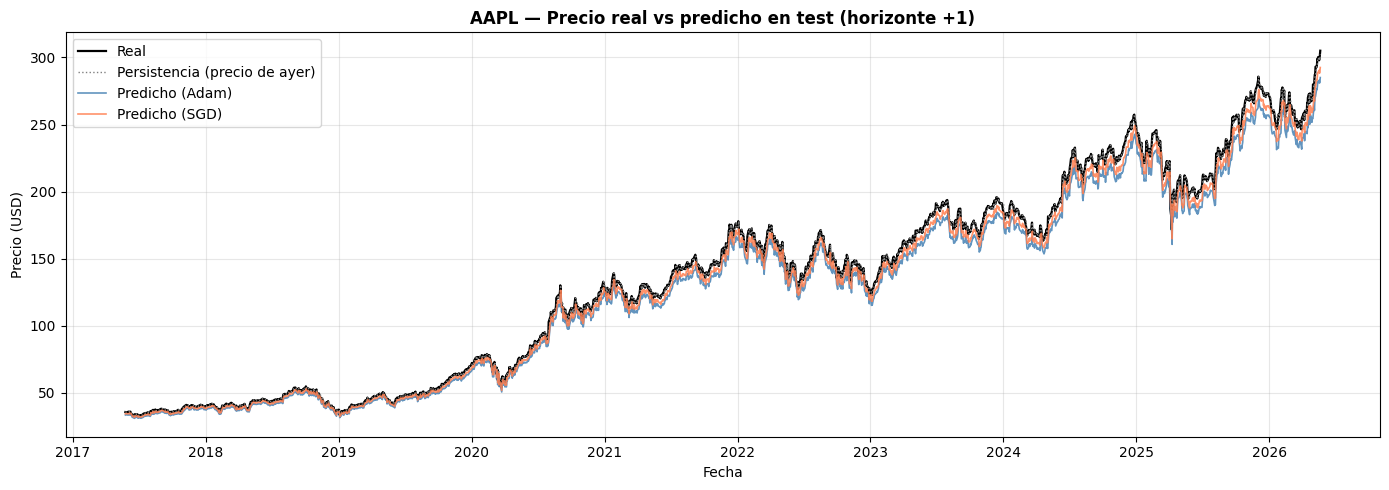

  Gráfica guardada: real_vs_pred_serie_AAPL.png


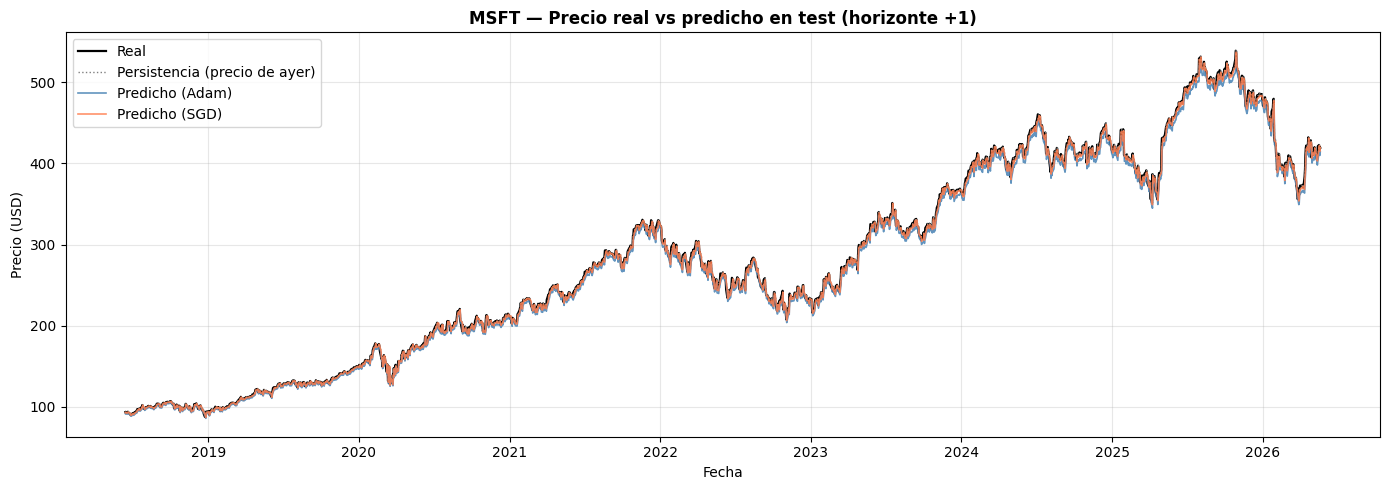

  Gráfica guardada: real_vs_pred_serie_MSFT.png


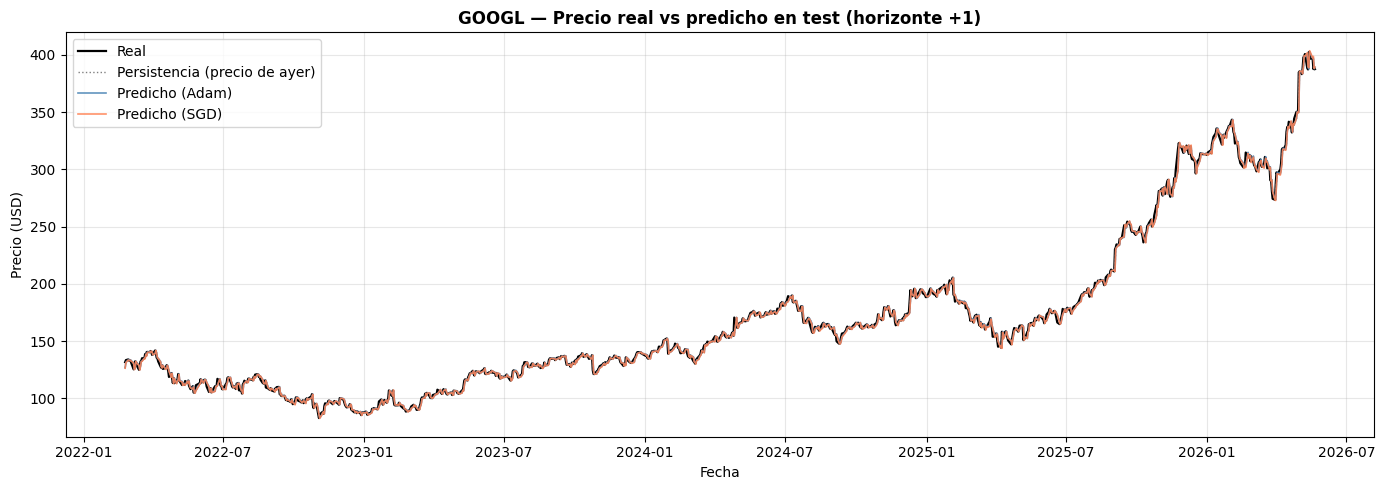

  Gráfica guardada: real_vs_pred_serie_GOOGL.png


In [15]:
# ─────────────────────────────────────────────────────────────────
# Precio real vs predicho a lo largo de TODO el test (predicción a +PASO+1 día).
# Funciona con OUTPUT_LEN=1 (la gráfica por ventanas degenera en ese caso).
# Incluye el baseline ingenuo "mañana = hoy" (persistencia) para que se vea
# que los modelos básicamente copian el último precio conocido.
# ─────────────────────────────────────────────────────────────────
PASO = 0  # día del horizonte a graficar (0 = el +1). Solo relevante si OUTPUT_LEN > 1.

colores = {'Adam': 'steelblue', 'SGD': 'coral'}

for ticker in TICKERS:                                   # Una figura por empresa.
    df_t      = datos_limpios[ticker]
    scaler    = scalers[ticker]
    split_idx = split_indices[ticker]
    serie     = df_t['LogReturn'].values
    closes    = df_t['Close'].values

    # Secuencias de test (misma convención que la evaluación)
    serie_test_scaled = scaler.transform(serie[split_idx:].reshape(-1, 1)).flatten()
    X_te, y_te = crear_secuencias(serie_test_scaled, INPUT_LEN, OUTPUT_LEN)
    X_te_t      = torch.tensor(X_te, dtype=torch.float32)
    real_logret = scaler.inverse_transform(y_te)

    n      = len(real_logret)
    fechas = [df_t['Date'].iloc[split_idx + i + INPUT_LEN + PASO] for i in range(n)]
    anclas = np.array([closes[split_idx + i + INPUT_LEN - 1] for i in range(n)])      # último precio conocido
    real_usd = anclas * np.array([np.exp(np.cumsum(real_logret[i])[PASO]) for i in range(n)])

    plt.figure(figsize=(14, 5))
    plt.plot(fechas, real_usd, color='black', linewidth=1.6, label='Real')
    plt.plot(fechas, anclas, color='gray', linewidth=1.0, linestyle=':',
             label='Persistencia (precio de ayer)')

    for nombre, modelo in modelos.items():               # Adam y SGD
        modelo.eval()
        with torch.no_grad():
            pred_logret = scaler.inverse_transform(modelo(X_te_t).numpy())
        pred_usd = anclas * np.array([np.exp(np.cumsum(pred_logret[i])[PASO]) for i in range(n)])
        plt.plot(fechas, pred_usd, color=colores.get(nombre), linewidth=1.2,
                 alpha=0.85, label=f'Predicho ({nombre})')

    plt.title(f'{ticker} — Precio real vs predicho en test (horizonte +{PASO + 1})',
              fontsize=12, fontweight='bold')
    plt.xlabel('Fecha'); plt.ylabel('Precio (USD)')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
    fn = f'real_vs_pred_serie_{ticker}.png'
    plt.savefig(fn, dpi=150, bbox_inches='tight'); plt.show()
    print(f'  Gráfica guardada: {fn}')


## Conclusiones

In [18]:
# ─────────────────────────────────────────────────────────────────
# Resumen automático de resultados
# ─────────────────────────────────────────────────────────────────

# ── Resumen MLP por optimizador ────────────────────────────────────
# Agrupa los resultados de los modelos MLP por optimizador y calcula el promedio de las métricas.
resumen_mlp = df_mlp.groupby('Optimizador')[
    ['MAE ($)', 'RMSE ($)', 'Dir. Acc MLP (%)']].mean()

# Identifica el optimizador con el menor Error Absoluto Medio (MAE).
mejor_mae = resumen_mlp['MAE ($)'].idxmin()
# Identifica el optimizador con la mayor Precisión Direccional.
mejor_dir = resumen_mlp['Dir. Acc MLP (%)'].idxmax()

# ── Ganador en precisión direccional (MLP vs Markov) ──────────────
# Obtiene la Precisión Direccional del modelo Adam.
acc_adam   = resumen_mlp.loc['Adam', 'Dir. Acc MLP (%)']
# Obtiene la Precisión Direccional del modelo SGD.
acc_sgd    = resumen_mlp.loc['SGD',  'Dir. Acc MLP (%)']

# Crea un diccionario con los resultados de precisión direccional de todos los candidatos (Adam, SGD, Markov).
candidatos = {
    'Adam'  : acc_adam,
    'SGD'   : acc_sgd,
}
# Determina el candidato con la mayor precisión direccional.
ganador_dir = max(candidatos, key=candidatos.get)

print('=' * 60)
print('  CONCLUSIONES AUTOMÁTICAS')
print('=' * 60)

print(f'\n  Entrenamiento:')
# Imprime el número de épocas de entrenamiento para Adam y SGD.
print(f'    Épocas — Adam : {len(hist_adam):>3} | SGD : {len(hist_sgd):>3}')
# Imprime la pérdida final de entrenamiento para Adam y SGD.
print(f'    Loss final — Adam : {hist_adam[-1]:.6f} | SGD : {hist_sgd[-1]:.6f}')

print(f'\n  Métricas MLP (promedio entre empresas):')
# Imprime las métricas promedio de los modelos MLP, redondeadas a 2 decimales.
print(resumen_mlp.round(2).to_string())


print(f'\n  Comparación direccional global:')
# Imprime la precisión direccional de Adam.
print(f'    Adam   : {acc_adam:.1f}%')
# Imprime la precisión direccional de SGD.
print(f'    SGD    : {acc_sgd:.1f}%')
# Imprime el ganador de la precisión direccional.
print(f'    Ganador: {ganador_dir} 🏆')

print(f'\n  Mejor MAE  (MLP): {mejor_mae}')
print(f'  Mejor Dir  (MLP): {mejor_dir}')

print(f'\n  Regularizaciones aplicadas:')
print(f'    ✔ Dropout (p=0.2) en Encoder y Decoder')
print(f'    ✔ Weight Decay L2 (1e-4) en Adam y SGD')
print(f'    ✔ Early Stopping (paciencia=10 épocas)')

print('=' * 60)

# ─────────────────────────────────────────────────────────────────
# SALIDA RECUPERABLE: guarda todos los resultados en resultados.json
# (esto es lo que FastAPI lee y devuelve)
# ─────────────────────────────────────────────────────────────────
import json as _json

resultados = {
    'entrenamiento': {
        'epocas':     {'Adam': int(len(hist_adam)), 'SGD': int(len(hist_sgd))},
        'loss_final': {'Adam': round(float(hist_adam[-1]), 6),
                       'SGD':  round(float(hist_sgd[-1]),  6)},
    },
    'metricas_mlp_promedio': resumen_mlp.round(4).to_dict('index'),
    'metricas_por_empresa':  df_mlp.to_dict('records'),
    'direccional_global': {
        'Adam':   round(float(acc_adam), 1),
        'SGD':    round(float(acc_sgd), 1),
    },
    'ganador_direccional': ganador_dir,
    'mejor_mae_mlp':       mejor_mae,
    'mejor_dir_mlp':       mejor_dir,
    'graficas': [f'real_vs_pred_serie_{t}.png' for t in TICKERS],
}

with open('resultados.json', 'w', encoding='utf-8') as _f:
    _json.dump(resultados, _f, ensure_ascii=False, indent=2)

print('\n>>> resultados.json guardado')


  CONCLUSIONES AUTOMÁTICAS

  Entrenamiento:
    Épocas — Adam :  23 | SGD :  21
    Loss final — Adam : 0.002102 | SGD : 0.002592

  Métricas MLP (promedio entre empresas):
             MAE ($)  RMSE ($)  Dir. Acc MLP (%)
Optimizador                                     
Adam            5.36      6.72             38.73
SGD             3.61      4.88             57.93

  Comparación direccional global:
    Adam   : 38.7%
    SGD    : 57.9%
    Ganador: SGD 🏆

  Mejor MAE  (MLP): SGD
  Mejor Dir  (MLP): SGD

  Regularizaciones aplicadas:
    ✔ Dropout (p=0.2) en Encoder y Decoder
    ✔ Weight Decay L2 (1e-4) en Adam y SGD
    ✔ Early Stopping (paciencia=10 épocas)

>>> resultados.json guardado
